# Analyse de la décote des produits d'occasion

Marya Khelifa et Nour Bouabid

In [240]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [267]:
df=pd.read_csv('data_final.csv', encoding="utf-8-sig")

# Table des Matières
1. [Analyse descriptive](#part1)
    - [ Présentation générale et statistiques descriptives](#part1sec1)
    - [Analyse du prix](#part1sec2)
    - [Analyse de la décote](#part1sec3)
2. [Analyse non supervisée](#part2)
    - [Clustering](#part2sec1)
    - [Boxplots par cluster](#part2sec2)
    - [Visualisation ACP en deux dimensions](#part2sec3)
3. [Analyse supervisée](#part3)
    - [Prétraitement des variables](#part3sec1)
    - [Regression Ridge](#part3sec2)
    - [Performances et Résultats](#part3sec3)
    - [Interprétation des coefficients Ridge](#part3sec4)

## I.Analyse descriptive <a id="part1"></a>

### 1. Présentation générale et statistiques descriptives <a id="part1sec1"></a>

In [268]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   etat             384 non-null    object 
 1   matiere          384 non-null    object 
 2   couleur          384 non-null    object 
 3   categorie        384 non-null    object 
 4   likes            384 non-null    float64
 5   prix             384 non-null    float64
 6   prix_total       384 non-null    float64
 7   collection       384 non-null    object 
 8   prix_moyen_zara  384 non-null    float64
 9   decote           384 non-null    float64
dtypes: float64(5), object(5)
memory usage: 30.1+ KB


In [ ]:
# statistiques descriptives des variables quantitatives
colonnes_num = ["likes", "prix", "prix_total", "prix_moyen_zara", "decote"]

df[colonnes_num].describe()

,likes,prix,prix_total,prix_moyen_zara,decote
count,384.000000,384.000000,384.000000,384.000000,384.000000
mean,29.268229,13.994453,15.353698,33.135282,0.467696
std,32.476035,16.269817,17.232584,21.033422,0.693920
min,0.000000,2.000000,2.800000,6.950000,-5.071119
25%,9.750000,5.000000,5.950000,22.137500,0.335681
50%,19.000000,9.100000,10.170000,29.950000,0.711493
75%,37.000000,15.000000,16.450000,35.950000,0.833102
max,222.000000,175.000000,184.450000,159.000000,0.957983


In [ ]:
# Statistiques descriptive complète des variables qualitatives

colonnes_qualitatives = [
    "categorie",
    "etat",
    "matiere",
    "couleur",
    "collection"
]

for col in colonnes_qualitatives:
    print(f"\n===== {col.upper()} =====")
    print(df[col].value_counts())


===== CATEGORIE =====
categorie
hauts et t-shirts                   100
pantalons et leggings                47
manteaux et vestes                   36
jeans                                34
robes                                31
chaussures                           27
sweats et sweats à capuche           27
blazers et tailleurs                 24
jupes                                13
accessoires                           9
combinaisons et combishorts           8
shorts                                8
vêtements de sport                    6
costumes et tenues particulières      4
autres                                3
jupes-shorts                          2
maillots de bain                      2
lingerie et pyjamas                   2
sacs                                  1
Name: count, dtype: int64

===== ETAT =====
etat
très bon état          221
neuf sans étiquette     94
neuf avec étiquette     51
bon état                18
Name: count, dtype: int64

===== MATIERE =====
mat

In [276]:
# ===== FILTRAGE DES GROUPES AVEC AU MOINS 10 OBSERVATIONS =====
Dataset_final=df.copy()
# Catégories fréquentes
categories_valides = Dataset_final["categorie"].value_counts()
categories_valides = categories_valides[categories_valides >= 10].index

# Matières fréquentes
matieres_valides = Dataset_final["matiere"].value_counts()
matieres_valides = matieres_valides[matieres_valides >= 10].index

# Dataset filtré
Dataset_filtre = Dataset_final[
    (Dataset_final["categorie"].isin(categories_valides)) &
    (Dataset_final["matiere"].isin(matieres_valides))
    ]

print(Dataset_filtre.shape)

(336, 10)


### 2. Analyse du prix <a id="part1sec2"></a>

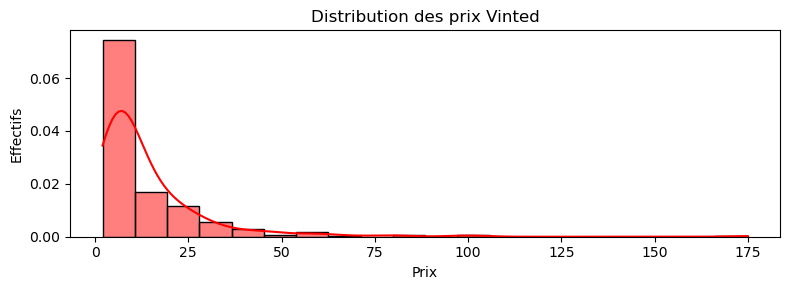

In [309]:
fig, ax = plt.subplots(1, figsize=(8, 3))

sns.histplot(
    data=Dataset_filtre,
    x="prix",
    bins=20,
    stat="density",
    kde=True,
    color="red",
    edgecolor="black",
    ax=ax
)

ax.set_title("Distribution des prix Vinted")
ax.set_xlabel("Prix")
ax.set_ylabel("Effectifs")

plt.tight_layout()
plt.show()

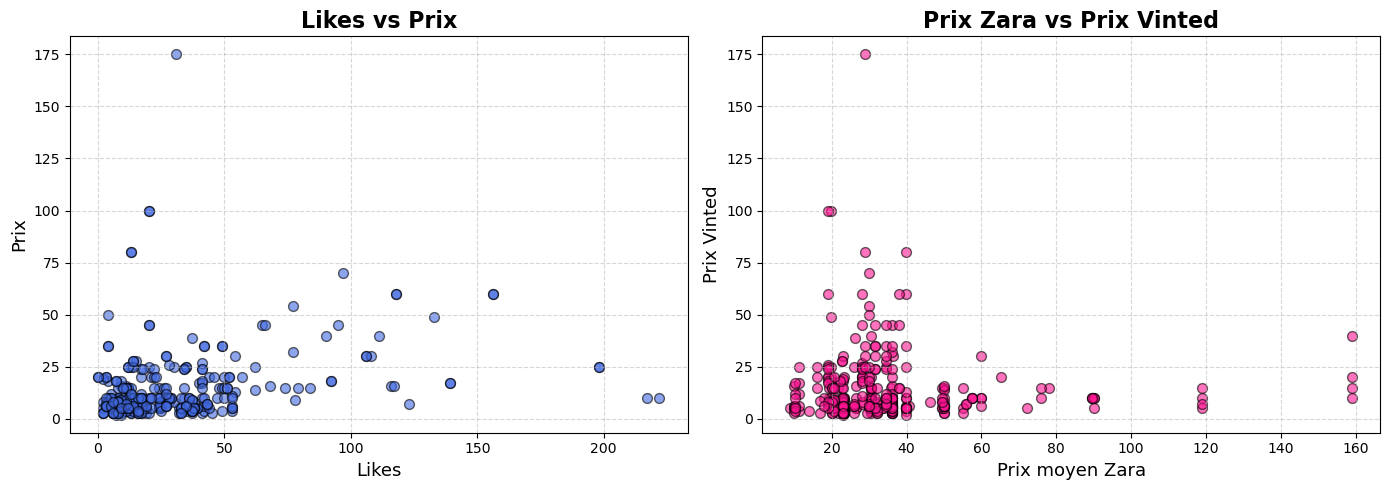

In [297]:
# Analyse bivariée prix d'occasion/ likes et prix d'occassion/prix neuf
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Likes vs Prix
ax[0].scatter(
    Dataset_filtre["likes"],
    Dataset_filtre["prix"],
    alpha=0.6,
    s=50,
    color="royalblue",
    edgecolors="black"
)

ax[0].set_title("Likes vs Prix",fontsize=16,fontweight="bold")
ax[0].set_xlabel("Likes",fontsize=13)
ax[0].set_ylabel("Prix",fontsize=13)
ax[0].grid(True, linestyle="--", alpha=0.5)

# Prix moyen Zara vs Prix
ax[1].scatter(
    Dataset_filtre["prix_moyen_zara"],
    Dataset_filtre["prix"],
    alpha=0.6,
    s=50,
    color="deeppink",
    edgecolors="black"
)

ax[1].set_title("Prix Zara vs Prix Vinted",fontsize=16,fontweight="bold")
ax[1].set_xlabel("Prix moyen Zara", fontsize=13)
ax[1].set_ylabel("Prix Vinted",fontsize=13)
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### 3. Analyse de la décote <a id="part1sec3"></a>

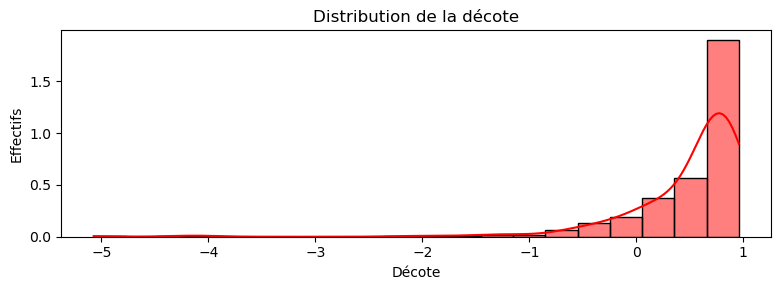

In [ ]:
#Distribution de la décote
fig, ax = plt.subplots(1, figsize=(8, 3))

sns.histplot(
    data=Dataset_filtre,
    x="decote",
    bins=20,
    stat="density",
    kde=True,
    color="red",
    edgecolor="black",
    ax=ax
)

ax.set_title("Distribution de la décote")
ax.set_xlabel("Décote")
ax.set_ylabel("Effectifs")

plt.tight_layout()
plt.show()

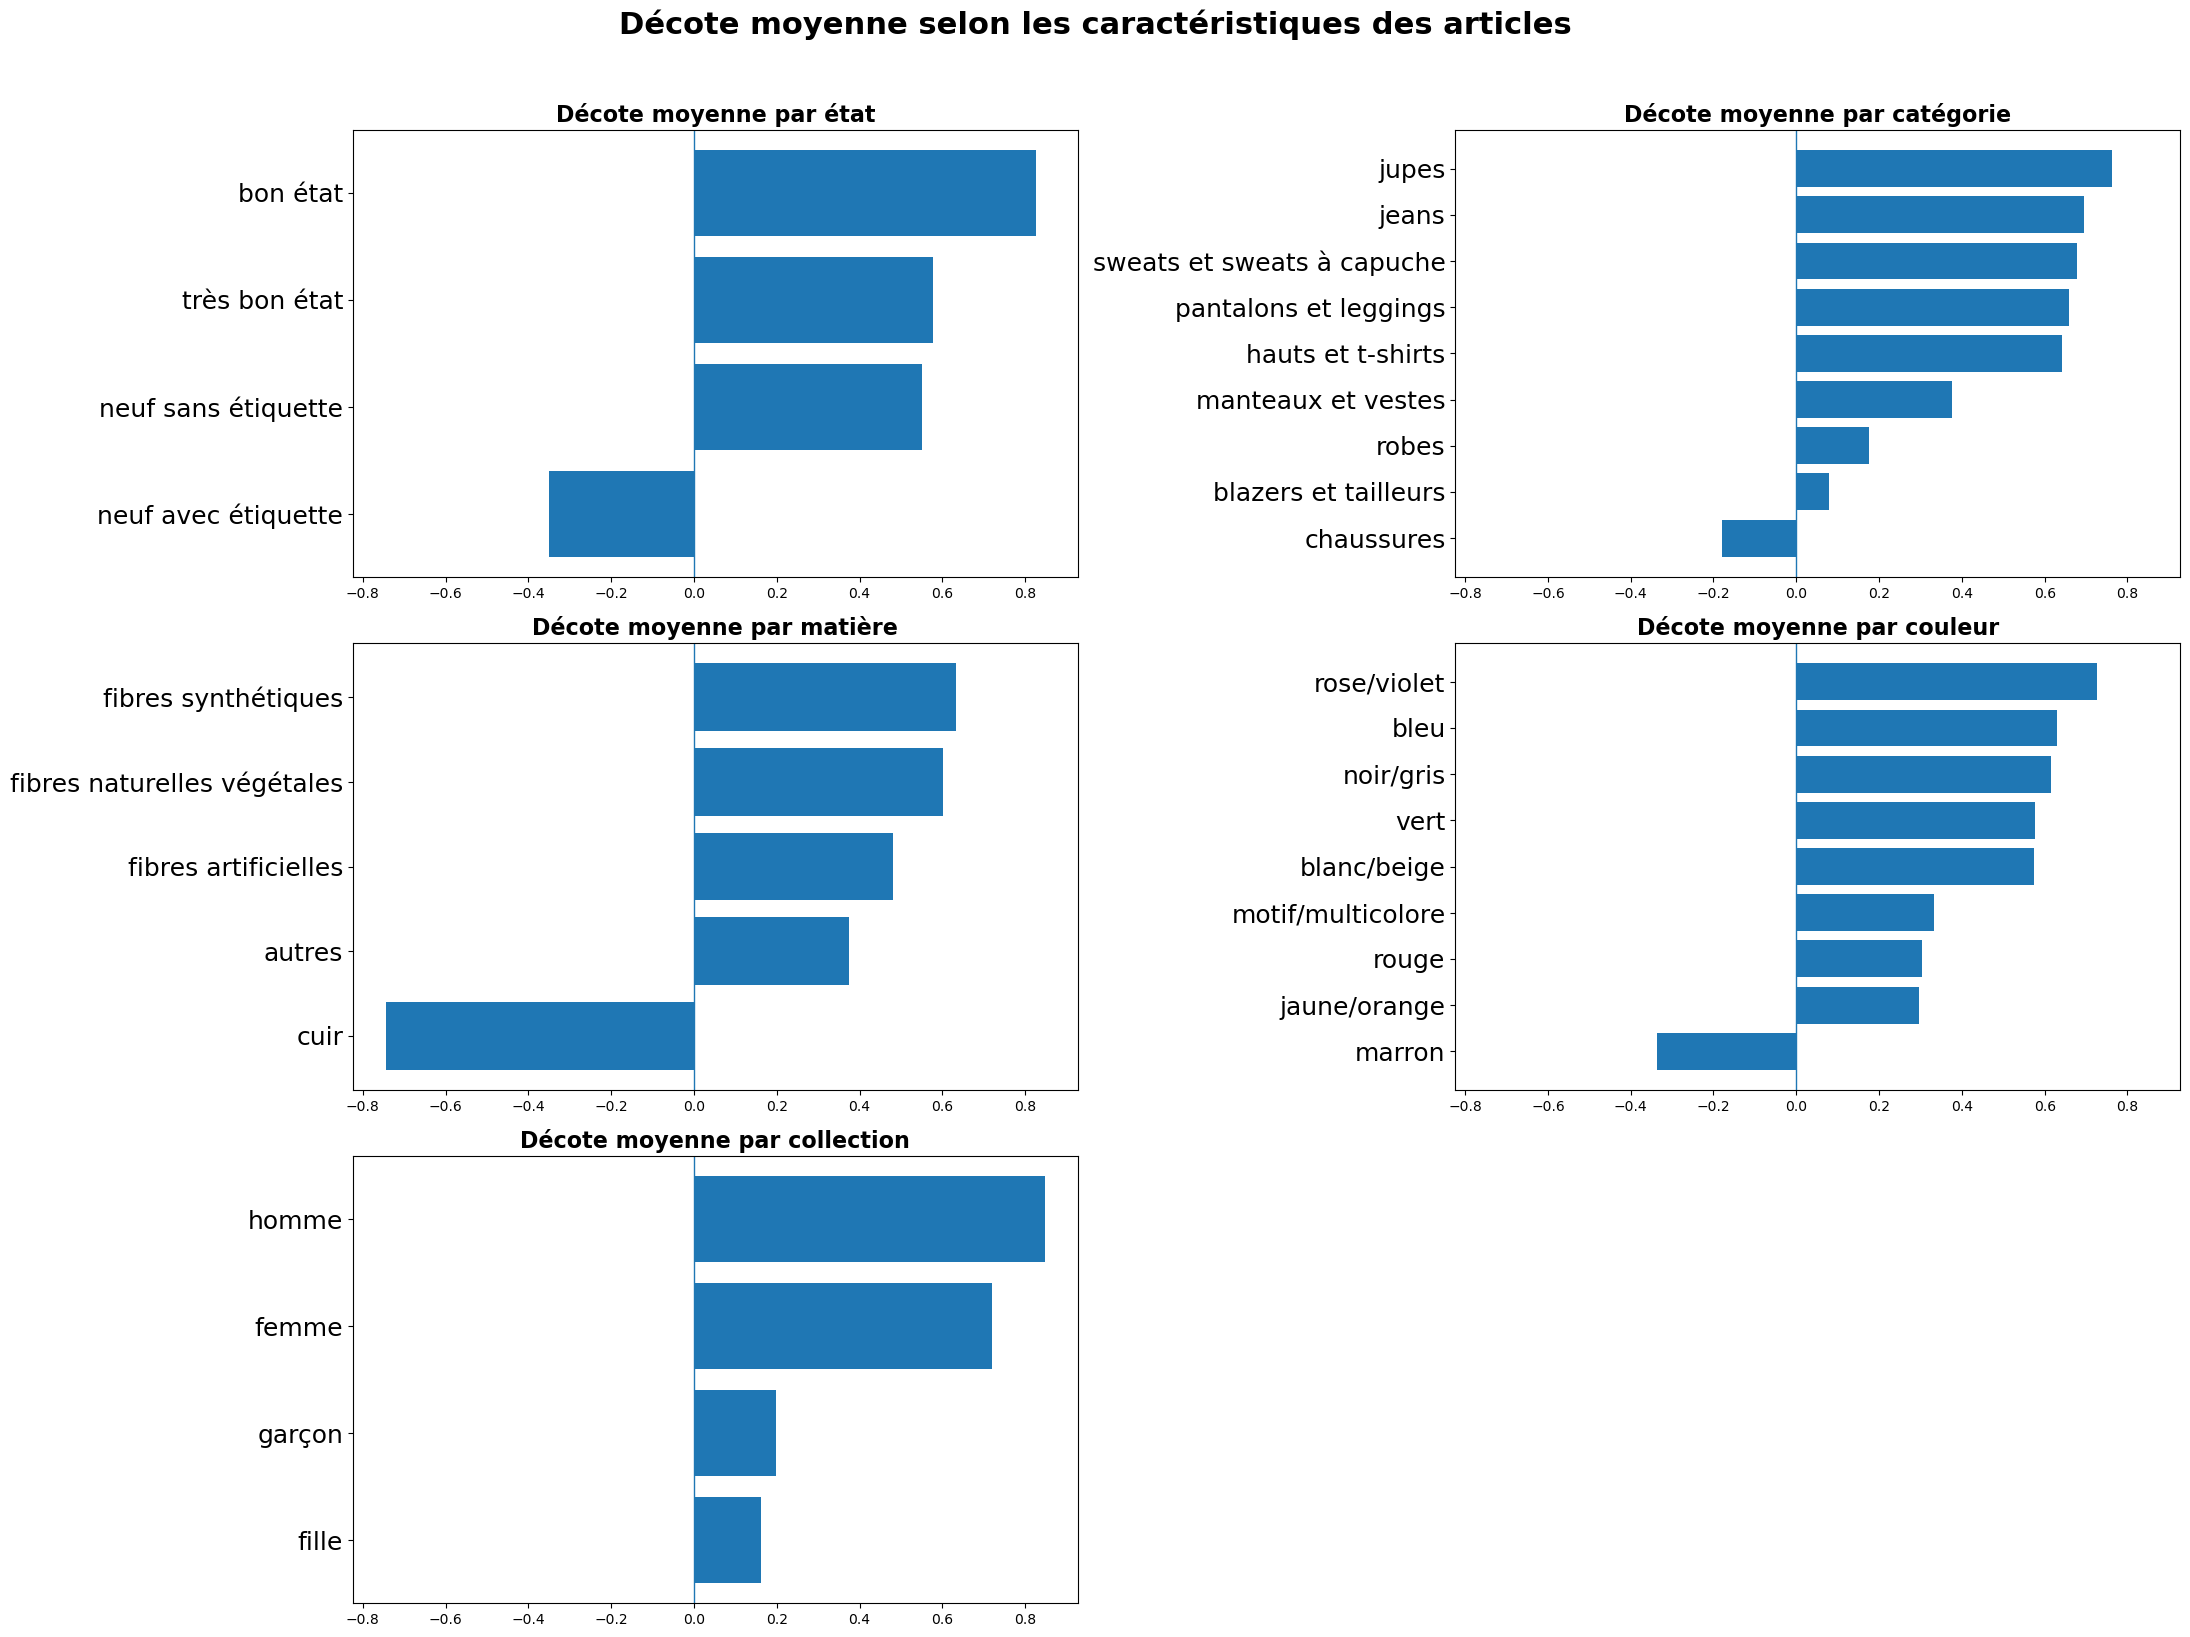

In [ ]:
#distribution de la décote par variables qualitatives

# Variables qualitatives à analyser
variables = ["etat", "categorie", "matiere", "couleur", "collection"]

titres = {
    "etat": "Décote moyenne par état",
    "categorie": "Décote moyenne par catégorie",
    "matiere": "Décote moyenne par matière",
    "couleur": "Décote moyenne par couleur",
    "collection": "Décote moyenne par collection"
}

# Calcul préalable des statistiques
stats = {}

for var in variables:
    temp = (
        Dataset_filtre.groupby(var)["decote"]
        .agg(moyenne="mean", effectif="count")
        .sort_values("moyenne")
    )
    stats[var] = temp

# Bornes communes pour tous les graphiques
valeurs = pd.concat([stats[var]["moyenne"] for var in variables])
xmin = min(0, valeurs.min())
xmax = valeurs.max()
marge = 0.05 * (xmax - xmin)
xmin -= marge
xmax += marge

# Création de la grille
fig, axes = plt.subplots(3, 2, figsize=(22, 16))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    temp = stats[var]

    # Labels avec effectifs
    labels = temp.index.astype(str)

    bars = ax.barh(
        labels,
        temp["moyenne"]
    )

    ax.set_title(titres[var], fontsize=16, fontweight="bold")
    ax.set_xlim(xmin, xmax)

    # Ligne verticale à 0, utile si certaines décotes sont négatives
    ax.axvline(0, linewidth=1)
    ax.tick_params(axis="y", labelsize=18)
    ax.grid(axis="x", alpha=0.3)

    # Suppression du dernier axe vide
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Décote moyenne selon les caractéristiques des articles",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

### 4. Corrélations entre variables qualitatives <a id="part1sec4"></a>

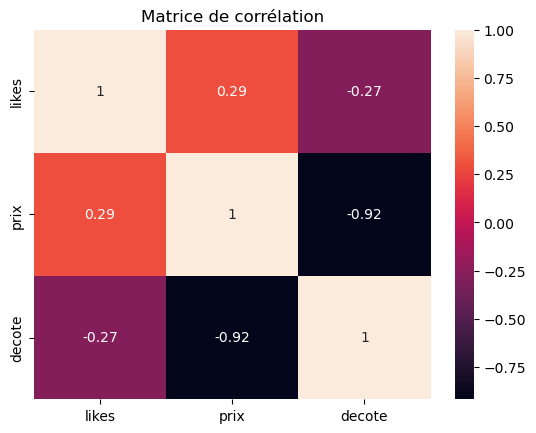

In [ ]:
#Analyse des corrélations
sns.heatmap(
    Dataset_filtre[
        [
            "likes",
            "prix",
            "decote"
        ]
    ].corr(),
    annot=True
)

plt.title("Matrice de corrélation")

plt.show()

## II. Analyse non supervisée <a id="part2"></a>

### 1. Clustering <a id="part2sec1"></a>

In [262]:
df_cluster= df.copy()
df_cluster=df_cluster.drop(columns=['prix_total', 'prix_moyen_zara' ]) 

In [263]:
#Prétraitement des variables
variables_num = ['likes', 'prix', 'decote']
variables_cat = ['etat', 'categorie', 'collection', 'matiere', 'couleur']

preprocessor=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_cat)
    ]
)


X_prepared = preprocessor.fit_transform(df_cluster)

In [264]:
#Choix du nombre de clusters
inerties = []
silhouettes = []

K_range = range(2,15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_prepared)
    
    inerties.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_prepared, labels))

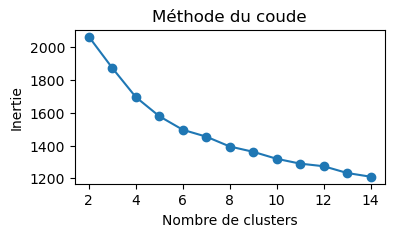

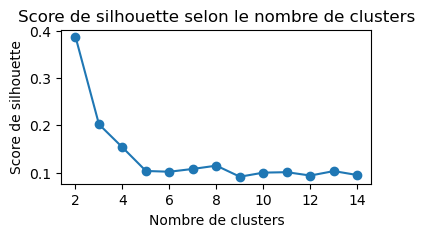

In [265]:
plt.figure(figsize=(4,2))
plt.plot(K_range, inerties, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode du coude")

plt.figure(figsize=(4,2))
plt.plot(K_range, silhouettes, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette selon le nombre de clusters")

plt.show()

In [266]:

k = 2

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_prepared)

df_cluster["cluster"] = labels

print(f"\nNombre de clusters : {k}")
print(f"Score de silhouette : {silhouette_score(X_prepared, labels):.3f}")

# Moyennes des variables numériques
moyennes = (
    df_cluster.groupby("cluster")[variables_num]
    .mean()
    .add_suffix("_moyenne")
)

# Effectifs et proportions
effectifs = df_cluster.groupby("cluster").size().rename("effectif")

proportions = (
    effectifs / len(df_cluster) * 100
).rename("proportion_%")

# Tableau final
resume_clusters = pd.concat(
    [ proportions,effectifs, moyennes],
    axis=1
).round(2)

display(resume_clusters)


Nombre de clusters : 2
Score de silhouette : 0.387


,proportion_%,effectif,likes_moyenne,prix_moyenne,decote_moyenne
cluster,,,,,
0,87.76,337,21.82,9.77,0.63
1,12.24,47,82.68,44.25,-0.73


### 2. Boxplots par clusters <a id="part2sec2"></a>

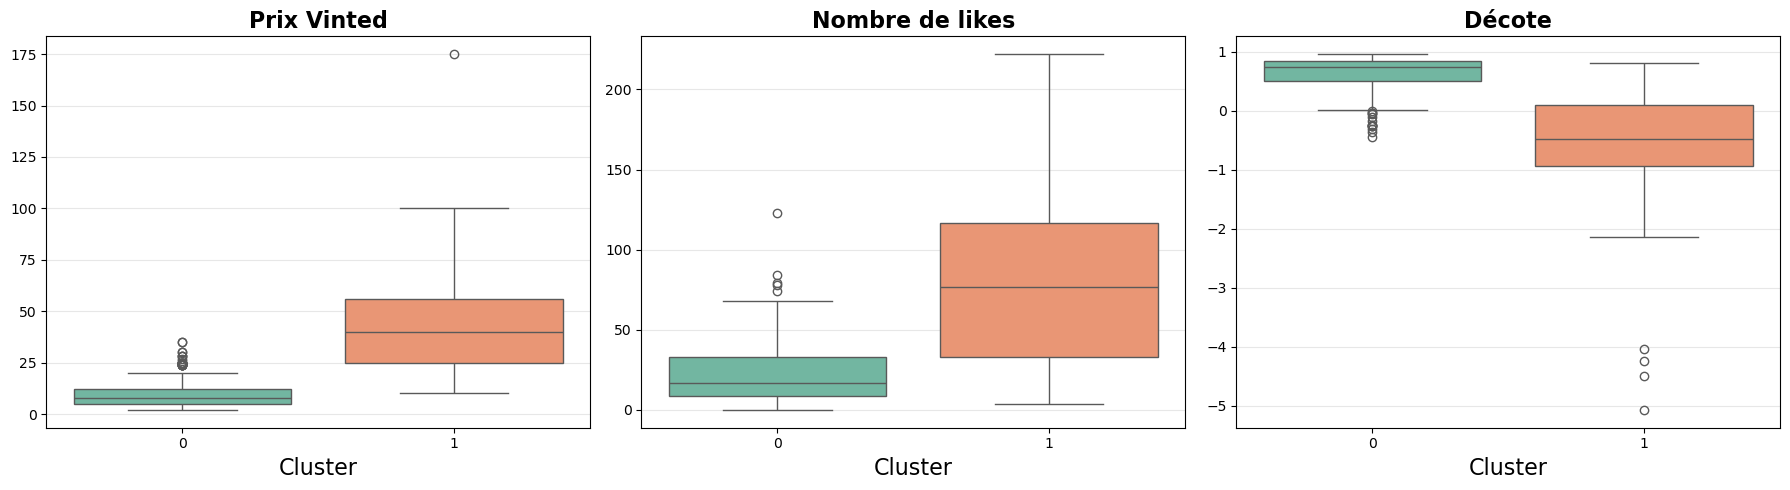

In [256]:
variables_box = ["prix", "likes", "decote"]

# Palette automatique selon le nombre de clusters
clusters = sorted(df_plot["cluster"].unique())
palette = sns.color_palette("Set2", n_colors=len(clusters))

# Création des graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titres = {
    "prix": "Prix Vinted",
    "likes": "Nombre de likes",
    "decote": "Décote"
}

for i, var in enumerate(variables_box):
    sns.boxplot(
        data=df_cluster,
        x="cluster",
        y=var,
        hue="cluster",
        palette=palette,
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(titres[var], fontsize=16, fontweight="bold")
    axes[i].set_xlabel("Cluster",fontsize=16)
    axes[i].set_ylabel(None)
    axes[i].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Visualisation ACP en deux dimensions <a id="part2sec3"></a>

In [94]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared)

df_cluster['ACP1'] = X_pca[:, 0]
df_cluster['ACP2'] = X_pca[:, 1]

In [95]:
print(f"Les deux premiers axes expliquent {pca.explained_variance_ratio_.sum()*100:.2f}% de la variance.")

Les deux premiers axes expliquent 45.07% de la variance.


In [96]:
feature_names = preprocessor.get_feature_names_out()

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=['ACP1', 'ACP2']
)

In [ ]:
#Variables contribuant le plus à l'axe 1
loadings['ACP1'].abs().sort_values(ascending=False).head(5)

num__prix                        0.647417
num__decote                      0.638541
num__likes                       0.316464
cat__etat_neuf avec étiquette    0.103530
cat__collection_fille            0.085884
Name: ACP1, dtype: float64

In [ ]:
#Variables contribuant le plus à l'axe 2
loadings['ACP2'].sort_values(ascending=True).head(5)

num__prix                                   -0.189980
cat__collection_garçon                      -0.075823
cat__etat_neuf sans étiquette               -0.045742
cat__categorie_sweats et sweats à capuche   -0.025596
cat__couleur_motif/multicolore              -0.021993
Name: ACP2, dtype: float64

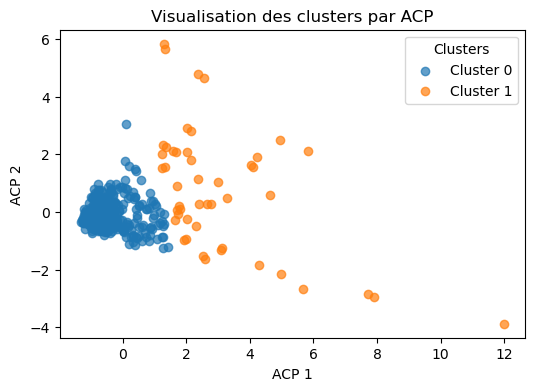

In [ ]:
#Visualisation
plt.figure(figsize=(6,4))
for cluster in sorted(df_cluster['cluster'].unique()):
    subset = df_cluster[df_cluster['cluster'] == cluster]
    plt.scatter(
        subset['ACP1'],
        subset['ACP2'],
        label=f'Cluster {cluster}',
        alpha=0.7
    )
plt.xlabel("ACP 1")
plt.ylabel("ACP 2")
plt.title("Visualisation des clusters par ACP")
plt.legend(title="Clusters")
plt.show()

# III. Analyse supervisée <a id="part3"></a>

### 1. Prétraitement des variables <a id="part3sec1"></a>

In [332]:
df_model=df.copy()
df_model=df_model.drop(columns=['prix_moyen_zara', 'prix_total'])

In [333]:
variables_num = ['likes']
variables_cat = ['etat', 'categorie', 'collection', 'matiere', 'couleur']
X=df_model[variables_num+variables_cat]
y=df_model['decote']


In [324]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [334]:
#Prétraitement des variables
preprocessor=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_cat)
    ]
)


X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

In [335]:
X_test_prepared.shape

(96, 42)

### 2. Regression Ridge <a id="part3sec2"></a>

In [315]:
#Choix de alpha pour regression Ridge
alphas = [0.01, 0.1, 1, 10, 100, 1000]

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}

for alpha in alphas:
    mse_test = []

    for train_index, test_index in kf.split(X):
        X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
        Y_tr, Y_te = Y.iloc[train_index], Y.iloc[test_index]

        X_tr = preprocessor.fit_transform(X_tr)
        X_te = preprocessor.transform(X_te)

        ridge = Ridge(alpha=alpha)
        ridge.fit(X_tr, Y_tr)

        Y_pred = ridge.predict(X_te)

        mse_test.append(mean_squared_error(Y_te, Y_pred))

    results[alpha] = np.mean(mse_test)

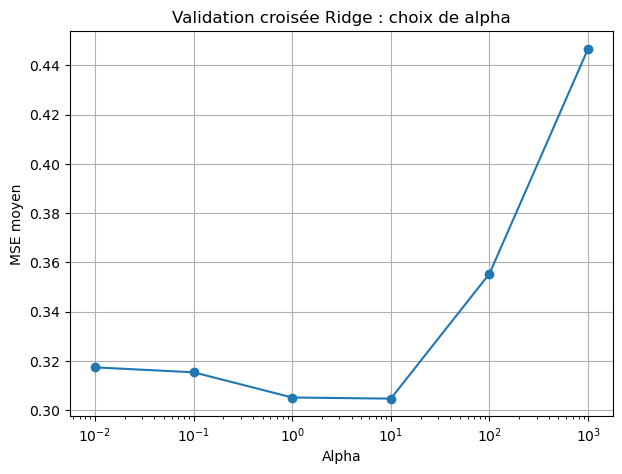

In [336]:
alphas_sorted = sorted(results.keys())
mse_values = [results[alpha] for alpha in alphas_sorted]

plt.figure(figsize=(7, 5))

plt.plot(alphas_sorted, mse_values, marker='o')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("MSE moyen")
plt.title("Validation croisée Ridge : choix de alpha")
plt.grid(True)

plt.show()

In [337]:
#entrainement du modèle
model= Ridge(alpha=10)
model.fit(X_train_prepared, y_train)

,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [338]:
#estimation et prédiction
y_estim = model.predict(X_train_prepared)
y_pred = model.predict(X_test_prepared)

### 3.Performances et résultats <a id="part3sec3"></a>

In [339]:
#indicateurs de performances
resultats = pd.DataFrame({
    "data": ["Train", "Test"],
    "R2": [
        r2_score(y_train, y_estim),
        r2_score(y_test, y_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_train, y_estim)),
        np.sqrt(mean_squared_error(y_test, y_pred))
    ]
})

resultats

,data,R2,RMSE
0,Train,0.457576,0.512451
1,Test,0.428544,0.514667


In [340]:
#stokage des coefficients Ridge

feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({ #si erreure de taille relancer le code depuis df_model=df.copy()
    "variable": feature_names,
    "coefficient": model.coef_
})

coef_df["coefficient_abs"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("coefficient_abs", ascending=False)

coef_df.head(5)

,variable,coefficient,coefficient_abs
6,cat__categorie_autres,-0.377667,0.377667
28,cat__matiere_cuir,-0.357168,0.357168
2,cat__etat_neuf avec étiquette,-0.307160,0.307160
7,cat__categorie_blazers et tailleurs,-0.295304,0.295304
24,cat__collection_fille,-0.280197,0.280197


In [342]:
#Stokage coefficient importants avec variable qualitatives et modalité associées
qual_cols = ["etat", "categorie", "matiere", "couleur", "collection"]

coef_modalites = coef_df.copy()
#filtrer les coefficients importants
coef_modalites = coef_modalites[coef_modalites["coefficient_abs"] > 0.1]

# filtrer les variables qualitatives
coef_modalites = coef_modalites[coef_modalites["variable"].str.startswith("cat__")]

def extraire_variable_modalite(nom_variable):
    nom = nom_variable.replace("cat__", "")
    
    for col in qual_cols:
        prefix = col + "_"
        if nom.startswith(prefix):
            modalite = nom.replace(prefix, "", 1)
            return pd.Series([col, modalite])
    
    return pd.Series([None, None])

coef_modalites[["variable_qualitative", "modalite"]] = coef_modalites["variable"].apply(extraire_variable_modalite)

coef_modalites["valeur"] = np.where(
    coef_modalites["coefficient"] < 0,
    "valorisé",
    "dévalorisé"
)

### 4. Interprétation des coefficients Ridge <a id="part3sec4"></a>

In [343]:
#calcul moyenne et median par modalité
stats_modalites = []

for col in qual_cols:
    temp = (
        df.groupby(col)["decote"]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
        .rename(columns={col: "modalite"})
    )
    
    temp["variable_qualitative"] = col
    stats_modalites.append(temp)

stats_modalites = pd.concat(stats_modalites, ignore_index=True)


In [344]:
#fusion moyenne et médiane par modalité et coefficient important associé
analyse_modalites = coef_modalites.merge(
    stats_modalites,
    on=["variable_qualitative", "modalite"],
    how="left"
)

analyse_modalites = analyse_modalites.sort_values(
    ["variable_qualitative", "coefficient"]
)

In [345]:
#affichage des resultats par variable qualitative et par conservation ou perte de valeur

for col in qual_cols:
    print("\n" + "="*80)
    print(f"Variable qualitative : {col}")
    print("="*80)
    
    temp = analyse_modalites[analyse_modalites["variable_qualitative"] == col]
    
    print("\nModalités associées à une conservation de valeur :")
    display(
        temp[temp["valeur"] == "valorisé"]
        .sort_values("coefficient")
        [["modalite", "coefficient", "count", "mean", "median"]].style.hide(axis="index")
    )
    
    print("\nModalités associées à perte de valeur :")
    display(
        temp[temp["valeur"] == "dévalorisé"]
        .sort_values("coefficient", ascending=False)
        [["modalite", "coefficient", "count", "mean", "median"]].style.hide(axis="index")
    )


Variable qualitative : etat

Modalités associées à une conservation de valeur :


modalite,coefficient,count,mean,median
neuf avec étiquette,-0.307160,51,-0.226861,0.056823



Modalités associées à perte de valeur :


modalite,coefficient,count,mean,median
bon état,0.109129,18,0.828306,0.852145
neuf sans étiquette,0.100290,94,0.555056,0.688029



Variable qualitative : categorie

Modalités associées à une conservation de valeur :


...

modalite,coefficient,count,mean,median
rose/violet,0.112884,10,0.727033,0.780328
noir/gris,0.112080,75,0.608226,0.749373



Variable qualitative : collection

Modalités associées à une conservation de valeur :


modalite,coefficient,count,mean,median
fille,-0.280197,96,0.115956,0.315903
garçon,-0.153688,96,0.199067,0.417285



Modalités associées à perte de valeur :


modalite,coefficient,count,mean,median
homme,0.263539,96,0.839930,0.874082
femme,0.170347,96,0.715830,0.759486


In [346]:
#affichage synthétique uniquement par variables
resume_groupes = (
    analyse_modalites
    .groupby(["variable_qualitative", "valeur"])
    .agg(
        nb_modalites=("modalite", "count"),
        coefficient_moyen=("coefficient", "mean"),
        decote_moyenne=("mean", "mean"),
        decote_mediane_moyenne=("median", "mean"),
        effectif_total=("count", "sum")
    )
    .reset_index().style.hide(axis="index")
)

resume_groupes

variable_qualitative,valeur,nb_modalites,coefficient_moyen,decote_moyenne,decote_mediane_moyenne,effectif_total
categorie,dévalorisé,3,0.135226,0.679961,0.752251,70
categorie,valorisé,3,-0.284870,-0.324908,0.578695,35
collection,dévalorisé,2,0.216943,0.777880,0.816784,192
collection,valorisé,2,-0.216943,0.157512,0.366594,192
couleur,dévalorisé,2,0.112482,0.667629,0.764851,85
couleur,valorisé,2,-0.109965,0.055088,0.433972,111
etat,dévalorisé,2,0.104710,0.691681,0.770087,112
etat,valorisé,1,-0.307160,-0.226861,0.056823,51
matiere,dévalorisé,1,0.163056,0.628004,0.749373,103
matiere,valorisé,1,-0.357168,-0.744100,-0.109350,21
